# d-Matrix Cluster vs GB200 NVL72 — Decode Pareto

**Question:** how does d-Matrix's SRAM-augmented LPDDR5 fabric stack up against GB200 NVL72 on GPT-1.8T MoE FP4 decode, with software-optimized collectives (no in-network collectives) and parallelism capped at the d-Matrix server radix?

**Three systems compared:**

| System | Devices | Per-device | Per-package equivalent | Fabric chain |
|--------|---------|-----------|--------------------------|--------------|
| GB200 NVL72 | 72 GPUs | 9 PFLOPs FP4 / GPU, 192 GB HBM3e @ 8 TB/s | 1 GPU = 1 package | NVLink5 (single tier, no INC here) |
| d-Matrix server | 64 chiplets | 1.2 PFLOPs FP4 / chiplet, 32 GB LPDDR5 @ 51.2 GB/s + 256 MB SRAM @ 18.75 TB/s | 4 chiplets = 1 package, 16 packages | pair_mesh → pcie_server |
| d-Matrix squadrack | 512 chiplets | same per-chiplet | 4 chiplets = 1 package, 128 packages | pair_mesh → pcie_server → ethernet_rack |

**Constraints (per the user spec):**
- TP ≤ 64, EP ≤ 64, **AND** TP·EP ≤ 64 — keeps parallelism within the d-Matrix server radix.
- SP = 1 (no sequence parallelism).
- PP fills the remaining device budget (PP · TP · EP · SP ≤ device count).
- All collectives software-optimized via `optimize_collective_algorithms` (`tp_algorithm=auto`, `ep_algorithm=auto`).
- INC disabled on all systems (`inc_enabled=False`) — d-Matrix has no SHARP-class fabric anyway; this disables NVLS on GB200 for fair comparison.
- Decode default placement on d-Matrix: `auto/auto, auto_priority='weights'` (Performance Mode). The 1.8T model far exceeds aggregate SRAM on either size, so weights end up on LPDDR5 either way; KV gets whatever SRAM remains.

**Plot axis convention:** Throughput per **package** vs Interactivity (1/TPOT). For d-Matrix, package = 4 chiplets (1 Corsair half-card); for GB200 NVL72, package = 1 GPU. So d-Matrix tput-per-package = 4 × tput-per-chiplet.

## 1. Imports and spec loading

In [1]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec

MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"
S_DECODE = 8192
BPP_FP4 = 0.5

# Three system specs to compare. Per-package conversion factor handles the
# chiplet-vs-GPU device-count mismatch in the Pareto plot below.
SYSTEM_FILES = {
    "GB200 NVL72":         ("llm_perf/database/system/gb200.nvl72.nvls.json", 1),  # 72 GPUs, 1 GPU/package
    "d-Matrix server":     ("llm_perf/database/system/dmatrix.server.json",     4),  # 64 chiplets, 4 chiplets/package
    "d-Matrix squadrack":  ("llm_perf/database/system/dmatrix.squadrack.json",  4),  # 512 chiplets, 4 chiplets/package
}

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4

systems = {}
for label, (path, _chiplets_per_pkg) in SYSTEM_FILES.items():
    systems[label] = load_system_spec(path)

tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  experts={model.moe.n_experts}  k_active={model.moe.k_active}  b={model.bytes_per_param}")
for label, sys in systems.items():
    chiplets_per_pkg = SYSTEM_FILES[label][1]
    n_pkg = sys.num_devices // chiplets_per_pkg
    chain = sys.collective_fabrics['TP'] if isinstance(sys.collective_fabrics['TP'], list) else [sys.collective_fabrics['TP']]
    print(f"\n{label}: {sys.num_devices} devices ({n_pkg} packages × {chiplets_per_pkg} chiplets-or-GPUs/pkg)")
    print(f"  fabric chain: {chain}")
    for t in sys.device.get_tiers():
        print(f"  memory tier {t.name:8s}  cap={t.capacity_GB:>7.3f} GB  bw={t.bandwidth_GBps:>10.1f} GB/s  η_β={t.eta_beta:.2f}")

Model:  GPT-1.8T-MoE  L=120  H=20480  n_kv=16  experts=16  k_active=2  b=0.5

GB200 NVL72: 72 devices (72 packages × 1 chiplets-or-GPUs/pkg)
  fabric chain: ['nvlink5']
  memory tier hbm       cap=192.000 GB  bw=    8000.0 GB/s  η_β=1.00

d-Matrix server: 64 devices (16 packages × 4 chiplets-or-GPUs/pkg)
  fabric chain: ['pair_mesh', 'pcie_server']
  memory tier sram      cap=  0.256 GB  bw=   18750.0 GB/s  η_β=1.00
  memory tier hbm       cap= 32.000 GB  bw=      51.2 GB/s  η_β=1.00

d-Matrix squadrack: 512 devices (128 packages × 4 chiplets-or-GPUs/pkg)
  fabric chain: ['pair_mesh', 'pcie_server', 'ethernet_rack']
  memory tier sram      cap=  0.256 GB  bw=   18750.0 GB/s  η_β=1.00
  memory tier hbm       cap= 32.000 GB  bw=      51.2 GB/s  η_β=1.00


## 2. Partition enumeration — `TP, EP ≤ 64` and `TP · EP ≤ 64`

Divisibility: `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`. The model's `n_experts=16` cap on EP is tighter than the user-specified 64, so EP effectively ranges over `{1, 2, 4, 8, 16}`. TP follows the same `n_kv` divisibility constraint; SP=1 throughout.

In [2]:
PP_CHOICES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60]
TP_CHOICES = [1, 2, 4, 8, 16]            # n_kv=16 cap
EP_CHOICES = [1, 2, 4, 8, 16]            # n_experts=16 cap (≤ user's 64 cap)
TP_EP_CAP = 64                            # joint cap from user spec


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                if tp * ep > TP_EP_CAP:
                    continue
                if pp * tp * ep > num_devices:
                    continue
                out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=1))
    return out


for label, sys in systems.items():
    parts = enumerate_partitions(sys.num_devices)
    print(f"  {label:22s}  {sys.num_devices:>4d} devices → {len(parts):>4d} valid partitions")

  GB200 NVL72               72 devices →  130 valid partitions
  d-Matrix server           64 devices →  130 valid partitions
  d-Matrix squadrack       512 devices →  276 valid partitions


## 3. Sweep — SW-optimized collectives, INC off, batch-size sweep per partition

For each (system, partition, B), we resolve the `auto` collective algorithms via `optimize_collective_algorithms` (which picks the SW choice that minimizes the per-call cost — `min(ring, DBT)` for star tiers, dim-decomposed ring on torus, hierarchical RS→sub-AR→AG on multi-tier crossbars). `inc_enabled=False` everywhere.

In [3]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_pkg: float          # tokens/s per package (4 chiplets on d-Matrix; 1 GPU on GB200)
    interactivity: float         # 1 / TPOT  [tokens/s per user]
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP}"


def make_sw_opt_tuner(base):
    t = deepcopy(base)
    t.tp_algorithm_decode = t.tp_algorithm_prefill = "auto"
    t.ep_algorithm_decode = t.ep_algorithm_prefill = "auto"
    t.inc_enabled = False
    return t


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_system(label: str) -> list[Point]:
    sys = systems[label]
    chiplets_per_pkg = SYSTEM_FILES[label][1]
    n_pkg = sys.num_devices // chiplets_per_pkg
    base = make_sw_opt_tuner(tuner_base)
    parts = enumerate_partitions(sys.num_devices)
    pts: list[Point] = []
    for partition in parts:
        try:
            mem = compute_memory(model, sys, partition, base)
        except Exception:
            continue
        paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
        kv = compute_kv_paging(model, sys, partition, base, mem, paging)
        b_max = int(kv.max_sequences)
        if b_max < 1:
            continue
        for B in log_spaced_batch_sizes(b_max):
            tuner = deepcopy(base)
            tuner.B_decode = B
            tuner = optimize_collective_algorithms(model, partition, sys, tuner)
            try:
                r = InferenceCalculator(model, sys, partition, tuner).run()
            except Exception:
                continue
            if r.latency.TPOT <= 0:
                continue
            pts.append(Point(
                partition=partition, B=B,
                tput_per_pkg=r.latency.TTPS / n_pkg,
                interactivity=1.0 / r.latency.TPOT,
                TPOT_ms=r.latency.TPOT * 1e3,
            ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_pkg, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_pkg)
    return frontier


all_points = {label: sweep_system(label) for label in systems}
frontiers = {label: pareto_frontier(all_points[label]) for label in systems}

for label in systems:
    print(f"  {label:22s}  cloud={len(all_points[label]):4d}  frontier={len(frontiers[label]):3d}")

  GB200 NVL72             cloud=3542  frontier= 47
  d-Matrix server         cloud= 863  frontier= 27
  d-Matrix squadrack      cloud=5053  frontier= 31


## 4. Combined Pareto plot in section 8

Both models' frontier plots are drawn together in section 8 (1×2 layout). Sections 5 below summarizes 1.8T per-corner picks first, then sections 6-7 introduce the 70B model and its sweep, and section 8 plots both.

## 5. Per-corner comparison

At three representative interactivity targets, what does each system pick (PP, TP, EP, B), what's its TPOT, and which fabric tiers are crossed?

In [4]:
def at_interactivity(fr: list[Point], target: float) -> Point | None:
    if not fr:
        return None
    return min(fr, key=lambda p: abs(math.log(p.interactivity / target)))


all_interacts = sorted({p.interactivity for fr in frontiers.values() for p in fr})
if all_interacts:
    targets = [
        all_interacts[len(all_interacts) // 6],          # high-throughput corner
        all_interacts[len(all_interacts) // 2],          # mid frontier
        all_interacts[5 * len(all_interacts) // 6],      # high-interactivity corner
    ]
    print(f"{'target int.':>14s}  {'system':22s}  {'partition':22s}  {'B':>5s}  {'TPOT (ms)':>10s}  {'tput/pkg':>10s}")
    print("-" * 100)
    for target in targets:
        for label in systems:
            p = at_interactivity(frontiers[label], target)
            if p is None:
                continue
            print(f"{target:>14.1f}  {label:22s}  {p.part_label:22s}  {p.B:>5d}  {p.TPOT_ms:>10.2f}  {p.tput_per_pkg:>10.0f}")
        print()

   target int.  system                  partition                   B   TPOT (ms)    tput/pkg
----------------------------------------------------------------------------------------------------
           3.1  GB200 NVL72             PP=24 TP=1 EP=1          1444       23.64        2545
           3.1  d-Matrix server         PP=8 TP=8 EP=1             65      320.83          13
           3.1  d-Matrix squadrack      PP=60 TP=8 EP=1          2700      311.28          68

          25.9  GB200 NVL72             PP=24 TP=1 EP=1          1444       23.64        2545
          25.9  d-Matrix server         PP=4 TP=16 EP=1             4      273.54           1
          25.9  d-Matrix squadrack      PP=60 TP=8 EP=1            66       38.56          13

         391.8  GB200 NVL72             PP=60 TP=1 EP=1           128        2.55         696
         391.8  d-Matrix server         PP=4 TP=16 EP=1             4      273.54           1
         391.8  d-Matrix squadrack      PP=30 TP=16

## 6. Takeaways

After running the notebook, look at:

- **Where each frontier lives.** GB200 NVL72 has 72 GPUs in a single NVLink5 domain (no inter-rack hop), so it dominates at high-interactivity corners where TP-bound collectives matter most. d-Matrix server has comparable per-package compute but a slower fabric ceiling once collectives cross PCIe; d-Matrix squadrack has more aggregate capacity but pays the ethernet tier when partitions span servers.
- **Where the d-Matrix curves diverge from each other.** The squadrack curve gains throughput-per-package wherever the partition stays inside a single server (TP·EP ≤ 64 by spec), and bleeds it back when the optimizer is forced to cross the ethernet tier — visible as the squadrack curve dropping below the server curve at high interactivity.
- **Memory-tier residency.** With GPT-1.8T at FP4 ≈ 0.9 TB and 64 chiplets × (256 MB SRAM + 32 GB LPDDR5) ≈ 16 GB SRAM + 2 TB LPDDR5 per server, weights fit in LPDDR5 only — placement defaults to weights-on-LPDDR5 and KV-on-SRAM in greedy mode. The Pareto curve reflects the LPDDR5 weight-load bottleneck.
- **Effect of the TP·EP ≤ 64 cap.** Without this cap, GB200 NVL72 could pick TP=64 EP=8 (the n_experts ceiling) at the high-interactivity end; capping at the d-Matrix server radix prevents it from claiming an unfair high-radix shard. d-Matrix server is unaffected (it's already physically capped); squadrack loses its full-rack-radix option.

Per-corner numbers in section 5 say which (PP, TP, EP, B) each system actually picks, and at what TPOT.

## 7. 70B MoE — same comparison, smaller model

Re-run the same sweep against a synthesized **70B-class MoE** (`gpt_70b_moe.json`): Llama-3-style attention backbone (L=32, H=8192, GQA `n_kv=8`) plus Mixtral-style 8-expert top-2 MoE per layer (I_moe=10240). Total ≈ 69B params, FP4 size ≈ 35 GB.

**Why this matters:** at FP4 the model is small enough that:
- d-Matrix server's aggregate LPDDR5 (2 TB) holds weights with margin; aggregate SRAM (16 GB across 64 chiplets) can hold ~half the weights at high TP shards.
- d-Matrix squadrack's aggregate SRAM (128 GB across 512 chiplets) **can hold all weights** at TP ≥ ~3 — finally letting Performance Mode keep weights SRAM-resident.
- GB200 NVL72's HBM (13.8 TB aggregate) is comically over-provisioned for a 70B model.

This is the regime where the SRAM-augmented architecture has a chance to actually win on per-package throughput. Comparing the 1.8T plot above to the 70B plot below shows how the d-Matrix Pareto curve moves when weights start fitting in SRAM.

In [5]:
# Snapshot the 1.8T results so they remain accessible alongside the 70B sweep below.
all_points_18t = all_points
frontiers_18t = frontiers
model_18t = model

# Rebind the global `model` to the 70B MoE spec. The sweep_system function picks
# up the new value via global lookup (Python late binding), so no refactor needed.
MODEL_70B = "llm_perf/database/model/gpt_70b_moe.json"
model = load_model_spec(MODEL_70B)
model.bytes_per_param = BPP_FP4

H_kv = model.H_kv()
attn_per_layer = 2 * model.H**2 + 2 * model.H * H_kv
ffn_per_layer = model.moe.n_experts * 3 * model.H * model.moe.I_moe
params = (attn_per_layer + ffn_per_layer) * model.L
print(f"Model:  {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  experts={model.moe.n_experts}  k_active={model.moe.k_active}")
print(f"  approx params: {params/1e9:.1f} B  (FP4 weight bytes ~ {params * BPP_FP4 / 1e9:.1f} GB)")

Model:  GPT-70B-MoE  L=32  H=8192  n_kv=8  experts=8  k_active=2
  approx params: 69.3 B  (FP4 weight bytes ~ 34.6 GB)


In [6]:
all_points_70b = {label: sweep_system(label) for label in systems}
frontiers_70b = {label: pareto_frontier(all_points_70b[label]) for label in systems}
for label in systems:
    print(f"  {label:22s}  cloud={len(all_points_70b[label]):4d}  frontier={len(frontiers_70b[label]):3d}")

  GB200 NVL72             cloud=5683  frontier= 47
  d-Matrix server         cloud=4214  frontier= 41
  d-Matrix squadrack      cloud=10453  frontier= 11


## 8. Combined Pareto plot — 1.8T and 70B side by side

Frontier curves only (no design-space scatter). System specs are listed in the footer block below the two axes.

/var/folders/70/pjyr2y156kzbtry8pjq__6100000gn/T/ipykernel_28528/3116383251.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


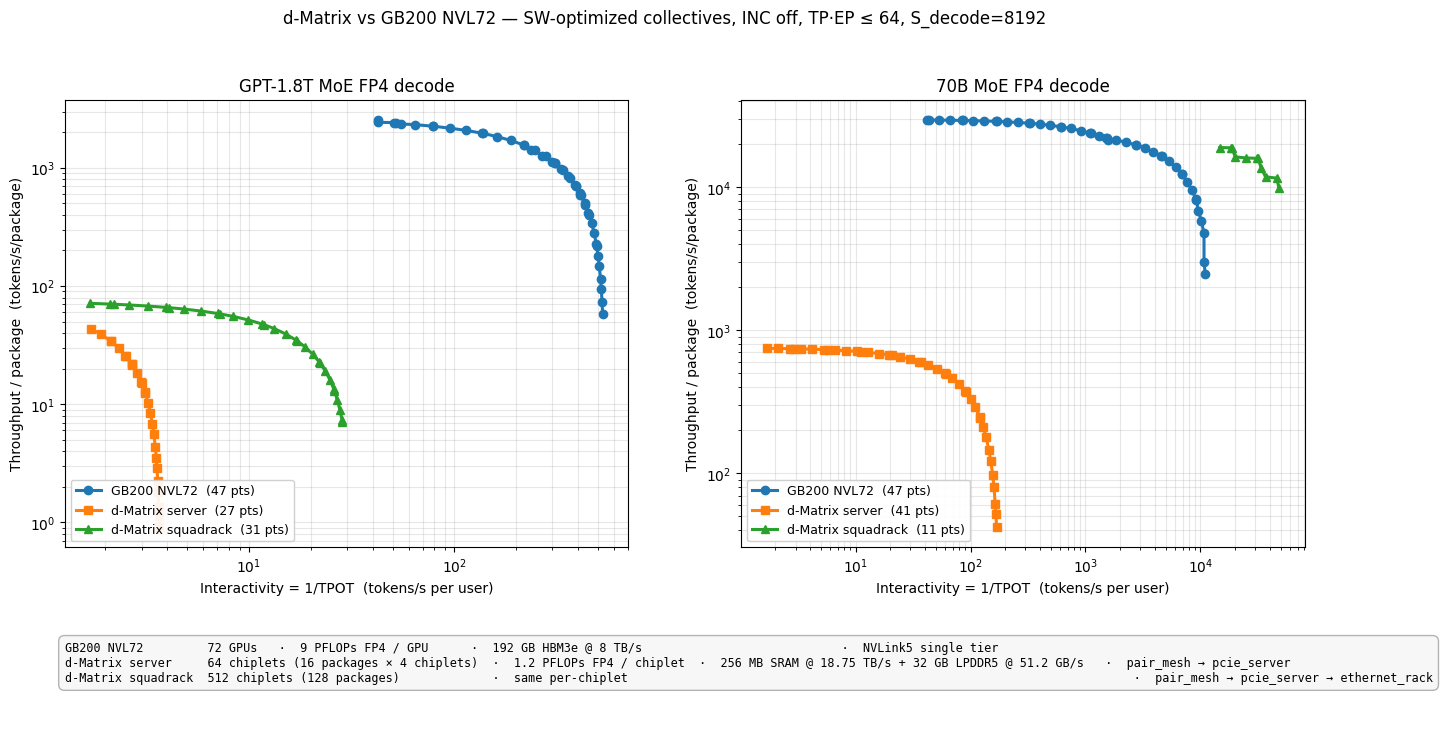

Saved → assets/pareto_dm_vs_gb200.png


In [7]:
STYLES = {
    "GB200 NVL72":         dict(color="tab:blue",   lw=2.2, ms=6, marker="o"),
    "d-Matrix server":     dict(color="tab:orange", lw=2.2, ms=6, marker="s"),
    "d-Matrix squadrack":  dict(color="tab:green",  lw=2.2, ms=6, marker="^"),
}

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 8.2))
gs = GridSpec(2, 2, height_ratios=[5, 1], figure=fig, hspace=0.35)
axL = fig.add_subplot(gs[0, 0])
axR = fig.add_subplot(gs[0, 1])
ax_text = fig.add_subplot(gs[1, :])
ax_text.axis("off")

panels = [
    (axL, frontiers_18t, "GPT-1.8T MoE FP4 decode"),
    (axR, frontiers_70b, "70B MoE FP4 decode"),
]

for ax, fronts, title in panels:
    for label in systems:
        fr = fronts[label]
        if not fr:
            continue
        style = STYLES[label]
        ax.plot([p.interactivity for p in fr], [p.tput_per_pkg for p in fr],
                color=style["color"], lw=style["lw"], marker=style["marker"],
                ms=style["ms"], label=f"{label}  ({len(fr)} pts)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Interactivity = 1/TPOT  (tokens/s per user)")
    ax.set_ylabel("Throughput / package  (tokens/s/package)")
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.92)

fig.suptitle(
    f"d-Matrix vs GB200 NVL72 — SW-optimized collectives, INC off, TP\u00b7EP \u2264 64, S_decode={S_DECODE}",
    fontsize=12, y=0.99,
)

# System spec footer block (lives in its own gridspec row, below both axes — never covers curves).
spec_text = (
    "GB200 NVL72         72 GPUs   \u00b7  9 PFLOPs FP4 / GPU      \u00b7  192 GB HBM3e @ 8 TB/s                            \u00b7  NVLink5 single tier\n"
    "d-Matrix server     64 chiplets (16 packages \u00d7 4 chiplets)  \u00b7  1.2 PFLOPs FP4 / chiplet  \u00b7  256 MB SRAM @ 18.75 TB/s + 32 GB LPDDR5 @ 51.2 GB/s   \u00b7  pair_mesh \u2192 pcie_server\n"
    "d-Matrix squadrack  512 chiplets (128 packages)             \u00b7  same per-chiplet                                                                       \u00b7  pair_mesh \u2192 pcie_server \u2192 ethernet_rack"
)
ax_text.text(
    0.0, 1.0, spec_text, transform=ax_text.transAxes,
    ha="left", va="top", fontsize=8.5, family="monospace",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f7f7f7", edgecolor="0.7"),
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("assets/pareto_dm_vs_gb200.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved \u2192 assets/pareto_dm_vs_gb200.png")

## 9. Per-corner comparison — 70B

In [8]:
all_interacts_70b = sorted({p.interactivity for fr in frontiers_70b.values() for p in fr})
if all_interacts_70b:
    targets = [
        all_interacts_70b[len(all_interacts_70b) // 6],
        all_interacts_70b[len(all_interacts_70b) // 2],
        all_interacts_70b[5 * len(all_interacts_70b) // 6],
    ]
    print(f"{'target int.':>14s}  {'system':22s}  {'partition':22s}  {'B':>5s}  {'TPOT (ms)':>10s}  {'tput/pkg':>10s}")
    print("-" * 100)
    for target in targets:
        for label in systems:
            p = at_interactivity(frontiers_70b[label], target)
            if p is None:
                continue
            print(f"{target:>14.1f}  {label:22s}  {p.part_label:22s}  {p.B:>5d}  {p.TPOT_ms:>10.2f}  {p.tput_per_pkg:>10.0f}")
        print()

   target int.  system                  partition                   B   TPOT (ms)    tput/pkg
----------------------------------------------------------------------------------------------------
          24.2  GB200 NVL72             PP=24 TP=1 EP=1         16839       23.80       29480
          24.2  d-Matrix server         PP=8 TP=8 EP=1            432       41.37         653
          24.2  d-Matrix squadrack      PP=60 TP=4 EP=1            82        0.07       18895

         168.6  GB200 NVL72             PP=24 TP=1 EP=1          4096        5.93       28799
         168.6  d-Matrix server         PP=4 TP=16 EP=1             4        5.93          42
         168.6  d-Matrix squadrack      PP=60 TP=4 EP=1            82        0.07       18895

        9197.5  GB200 NVL72             PP=60 TP=1 EP=1            64        0.11        8176
        9197.5  d-Matrix server         PP=4 TP=16 EP=1             4        5.93          42
        9197.5  d-Matrix squadrack      PP=60 TP=4 

## 10. Takeaways — 70B vs 1.8T

Two models, three systems, same Pareto axes. Compare the **70B plot (above)** with the **1.8T plot (section 4)**:

- **GB200 NVL72** stays bandwidth-bound by HBM3e on weight loads in both cases — the per-package frontier shape barely changes between the two models, just shifts down/right by the model-size ratio.
- **d-Matrix server** — for 1.8T, weights live entirely on LPDDR5 (slow tier dominates the per-token cost). For 70B, ~half the weights can fit in aggregate SRAM at high TP, partially relieving the LPDDR5 bottleneck.
- **d-Matrix squadrack** — for 1.8T, even 128 GB aggregate SRAM is far short of the 0.9 TB weight footprint. For 70B (35 GB FP4), aggregate SRAM is plenty and the squadrack frontier should approach a fully-SRAM-resident regime at moderate-to-high TP, where the per-package throughput improvement vs. the server is sharper.

The 70B plot is where the SRAM-residency argument from `sram.md §3.2` actually plays out — `t_mem` collapses toward microseconds as weights stay on the fast tier, leaving fabric and compute as the binding constraints.